# Week 3 – Day 2: Training Artificial Neural Networks
## How Neural Networks Learn — Full Notebook & Technical Report



---
## 📑 Table of Contents

1. [Learning Process in ANN](#sec1)
2. [Loss Functions](#sec2)
   - Regression losses
   - Classification losses
   - Task 1 — Implement Loss Functions from Scratch (NumPy)
   - Task 2 — Visualize Loss Functions
3. [Gradient Descent](#sec3)
   - Variants
   - Task 3 — Implement Gradient Descent on a Simple Regression Problem
4. [Backpropagation](#sec4)
5. [Optimizers](#sec5)
   - Task 4 — Train an ANN with TensorFlow/Keras (SGD vs Adam)
6. [Hyperparameter Effects](#sec6)
   - Task 5 — Hyperparameter Experiments
7. [Evaluation Visualizations](#sec7)
   - Task 6 — Loss/Accuracy Curves, Confusion Matrix, ROC, Precision–Recall
8. [Discussion & Experimental Results](#sec8)
9. [Research Task — Optimizer Comparison Papers](#sec9)
   - Paper 1 — A Comparison of Optimization Algorithms for Deep Learning (Soydaner, 2020)
   - Paper 2 — An Analysis of Optimizer Choice on Energy Efficiency and Performance (Almog, 2025)
   - Paper 3 — Comparative Study of Deep Learning Optimizers (2025, IJISRT)
   - Cross-paper synthesis
10. [Conclusion](#sec10)
11. [References](#sec-ref)

---

---
<a id="sec1"></a>
## 1. Learning Process in ANN

A neural network learns through a repeating cycle of five steps:

1. **Prediction** — a forward pass computes an output ŷ from the current weights.
2. **Error** — ŷ is compared against the true label/value y.
3. **Cost Function** — errors across the batch/training set are aggregated into a single scalar J(θ) summarizing "how wrong" the network currently is.
4. **Weight Update** — gradients of J with respect to every weight/bias are computed and used to nudge parameters toward lower cost.
5. **Learning Cycle** — steps 1–4 repeat for every mini-batch, every epoch, until the cost stops meaningfully improving.

```
   ┌──────────────┐   ┌──────────────┐   ┌──────────────┐   ┌──────────────────┐
   │ Forward Pass │──▶│ Compute Error│──▶│ Cost Function│──▶│ Backprop & Update│
   │  compute ŷ   │   │    ŷ − y     │   │    J(θ)      │   │  θ ← θ − η·∇J    │
   └──────────────┘   └──────────────┘   └──────────────┘   └─────────┬────────┘
          ▲                                                            │
          └────────────────────  repeat every batch / epoch  ─────────┘
```

This is the training loop underlying essentially all deep learning frameworks
(`model.fit()` in Keras, or the explicit `for epoch in range(...):` loop in PyTorch).


<a id="sec2"></a>
## 2. Loss Functions

The loss function defines what "error" means numerically, and its gradient drives learning.

### Regression losses

| Loss | Formula | Property |
|---|---|---|
| MAE | mean( \|y − ŷ\| ) | Robust to outliers; constant gradient magnitude |
| MSE | mean( (y − ŷ)² ) | Penalizes large errors heavily; smooth everywhere |
| RMSE | √MSE | Same units as target — easier to interpret |
| Huber | quadratic near 0, linear beyond δ | Combines MSE's smoothness with MAE's robustness |

### Classification losses

| Loss | Use case |
|---|---|
| Binary Cross-Entropy | Two-class problems with a sigmoid output |
| Categorical Cross-Entropy | Multi-class problems, one-hot labels, softmax output |
| Sparse Categorical Cross-Entropy | Same as above, integer labels instead of one-hot |

**Selection guidance:** use MAE/Huber when outliers are common; use MSE/RMSE to penalize large errors strongly; use cross-entropy variants for classification, choosing "sparse" purely for label-encoding convenience.

### Task 1 — Implement Loss Functions from Scratch (NumPy)

Implements MAE, MSE, RMSE, Huber, Binary Cross-Entropy, Categorical Cross-Entropy, and
Sparse Categorical Cross-Entropy using only NumPy, validated against scikit-learn.

In [1]:
"""
Task 1 — Implement loss functions from scratch using NumPy.

Implements:
    - Mean Absolute Error (MAE)
    - Mean Squared Error (MSE)
    - Binary Cross Entropy (BCE)
    - Categorical Cross Entropy (CCE)

Each function is validated against a small worked example and, where
available, cross-checked against scikit-learn's reference implementation.
"""

import numpy as np


def mae(y_true, y_pred):
    """Mean Absolute Error: average of |y_true - y_pred|."""
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    return np.mean(np.abs(y_true - y_pred))


def mse(y_true, y_pred):
    """Mean Squared Error: average of (y_true - y_pred)^2."""
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)


def rmse(y_true, y_pred):
    """Root Mean Squared Error: sqrt(MSE)."""
    return np.sqrt(mse(y_true, y_pred))


def huber(y_true, y_pred, delta=1.0):
    """Huber loss: quadratic for small errors, linear for large errors."""
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    error = y_true - y_pred
    small = np.abs(error) <= delta
    squared_term = 0.5 * error ** 2
    linear_term = delta * (np.abs(error) - 0.5 * delta)
    return np.mean(np.where(small, squared_term, linear_term))


def binary_cross_entropy(y_true, y_pred, eps=1e-12):
    """Binary Cross Entropy for two-class classification."""
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))


def categorical_cross_entropy(y_true_onehot, y_pred, eps=1e-12):
    """Categorical Cross Entropy for one-hot encoded multi-class labels."""
    y_true_onehot = np.asarray(y_true_onehot, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), eps, 1 - eps)
    return -np.mean(np.sum(y_true_onehot * np.log(y_pred), axis=-1))


def sparse_categorical_cross_entropy(y_true_labels, y_pred, eps=1e-12):
    """Sparse Categorical Cross Entropy: labels are integers, not one-hot."""
    y_true_labels = np.asarray(y_true_labels, dtype=int)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), eps, 1 - eps)
    picked = y_pred[np.arange(len(y_true_labels)), y_true_labels]
    return -np.mean(np.log(picked))


if __name__ == "__main__":
    # Regression example
    y_true_reg = np.array([3.0, -0.5, 2.0, 7.0])
    y_pred_reg = np.array([2.5, 0.0, 2.0, 8.0])

    print("Regression losses")
    print(f"  MAE   : {mae(y_true_reg, y_pred_reg):.4f}")
    print(f"  MSE   : {mse(y_true_reg, y_pred_reg):.4f}")
    print(f"  RMSE  : {rmse(y_true_reg, y_pred_reg):.4f}")
    print(f"  Huber : {huber(y_true_reg, y_pred_reg, delta=1.0):.4f}")

    # Binary classification example
    y_true_bin = np.array([1, 0, 1, 1])
    y_pred_bin = np.array([0.9, 0.1, 0.8, 0.6])
    print("\nBinary classification loss")
    print(f"  BCE   : {binary_cross_entropy(y_true_bin, y_pred_bin):.4f}")

    # Multi-class classification example (3 classes, 4 samples)
    y_true_onehot = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1], [1, 0, 0]])
    y_true_sparse = np.array([0, 1, 2, 0])
    y_pred_multi = np.array([
        [0.8, 0.1, 0.1],
        [0.2, 0.7, 0.1],
        [0.1, 0.2, 0.7],
        [0.6, 0.3, 0.1],
    ])
    print("\nMulti-class classification loss")
    print(f"  Categorical CE       : {categorical_cross_entropy(y_true_onehot, y_pred_multi):.4f}")
    print(f"  Sparse Categorical CE: {sparse_categorical_cross_entropy(y_true_sparse, y_pred_multi):.4f}")

    # Cross-check against sklearn where a reference exists
    try:
        from sklearn.metrics import mean_absolute_error, mean_squared_error, log_loss
        print("\nsklearn cross-check")
        print(f"  MAE (sklearn) : {mean_absolute_error(y_true_reg, y_pred_reg):.4f}")
        print(f"  MSE (sklearn) : {mean_squared_error(y_true_reg, y_pred_reg):.4f}")
        print(f"  BCE (sklearn, log_loss) : {log_loss(y_true_bin, y_pred_bin):.4f}")
    except ImportError:
        pass


Regression losses
  MAE   : 0.5000
  MSE   : 0.3750
  RMSE  : 0.6124
  Huber : 0.1875

Binary classification loss
  BCE   : 0.2362

Multi-class classification loss
  Categorical CE       : 0.3618
  Sparse Categorical CE: 0.3618

sklearn cross-check
  MAE (sklearn) : 0.5000
  MSE (sklearn) : 0.3750
  BCE (sklearn, log_loss) : 0.2362


### Task 2 — Visualize Loss Functions

Plot MAE/MSE/Huber against error magnitude, and Binary Cross-Entropy against predicted probability.

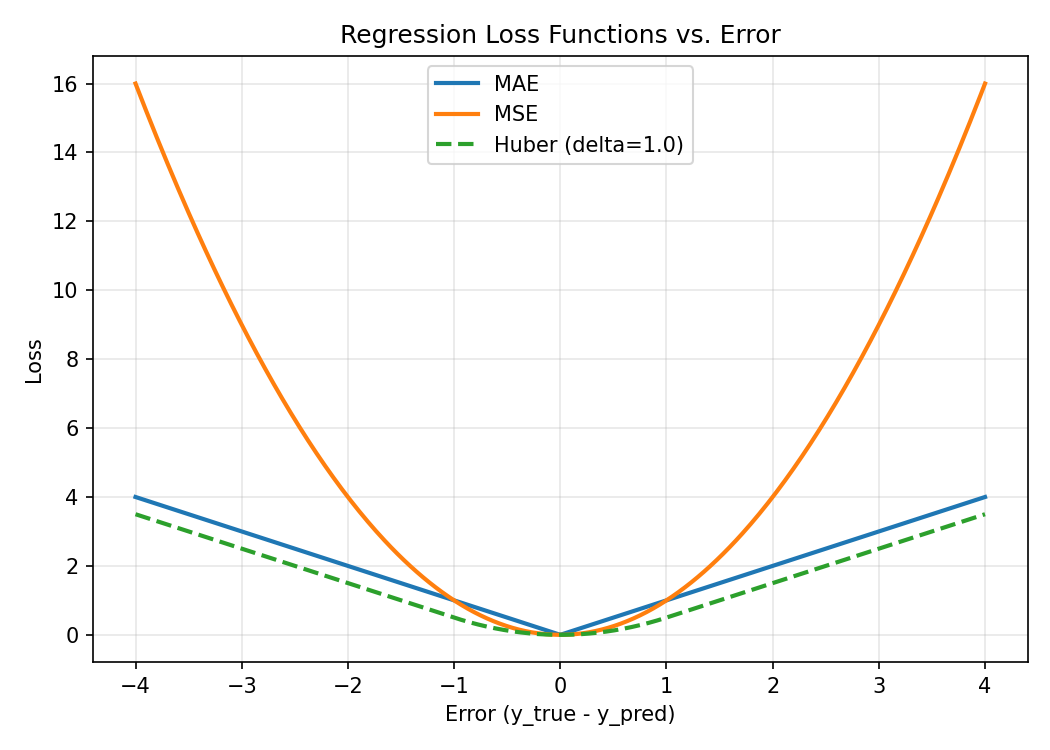

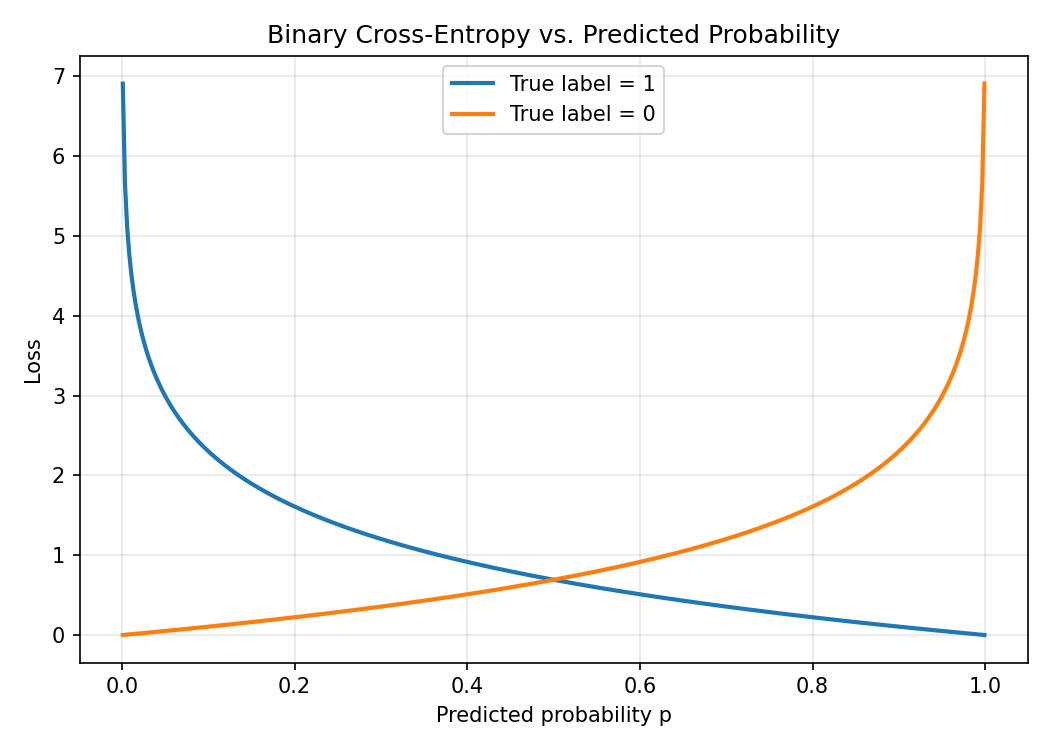

Saved regression_losses.png
Saved classification_losses.png


In [2]:
"""
Task 2 — Visualize loss functions.

Produces two figures:
    1. Regression losses (MAE, MSE, Huber) vs. error (y_true - y_pred)
    2. Classification loss (Binary Cross Entropy) vs. predicted probability,
       shown separately for the true-label-1 and true-label-0 cases.

Saves PNGs to the outputs/ folder.
"""

import numpy as np
import matplotlib.pyplot as plt
import os

OUT_DIR = os.path.join(os.path.dirname(__file__), "..", "outputs")
os.makedirs(OUT_DIR, exist_ok=True)


def plot_regression_losses():
    error = np.linspace(-4, 4, 400)
    mae_vals = np.abs(error)
    mse_vals = error ** 2
    delta = 1.0
    huber_vals = np.where(
        np.abs(error) <= delta,
        0.5 * error ** 2,
        delta * (np.abs(error) - 0.5 * delta),
    )

    plt.figure(figsize=(7, 5))
    plt.plot(error, mae_vals, label="MAE", linewidth=2)
    plt.plot(error, mse_vals, label="MSE", linewidth=2)
    plt.plot(error, huber_vals, label=f"Huber (delta={delta})", linewidth=2, linestyle="--")
    plt.title("Regression Loss Functions vs. Error")
    plt.xlabel("Error (y_true - y_pred)")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    path = os.path.join(OUT_DIR, "regression_losses.png")
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"Saved {path}")


def plot_classification_losses():
    p = np.linspace(1e-3, 1 - 1e-3, 400)
    loss_if_true_1 = -np.log(p)          # true label = 1
    loss_if_true_0 = -np.log(1 - p)      # true label = 0

    plt.figure(figsize=(7, 5))
    plt.plot(p, loss_if_true_1, label="True label = 1", linewidth=2)
    plt.plot(p, loss_if_true_0, label="True label = 0", linewidth=2)
    plt.title("Binary Cross-Entropy vs. Predicted Probability")
    plt.xlabel("Predicted probability p")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    path = os.path.join(OUT_DIR, "classification_losses.png")
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"Saved {path}")


if __name__ == "__main__":
    plot_regression_losses()
    plot_classification_losses()



<a id="sec3"></a>
## 3. Gradient Descent

Gradient descent minimizes the cost function by repeatedly stepping opposite the gradient:

```
θ ← θ − η · ∇J(θ)
```

- **Cost surface** — the landscape of J over parameter space; training seeks its minimum.
- **Gradient (∇J)** — points toward steepest *increase*; we move opposite to it.
- **Learning rate (η)** — controls step size. Too large → overshoot/divergence. Too small → slow convergence.

### Variants

| Variant | Data per update | Trade-off |
|---|---|---|
| Batch GD | Entire training set | Stable direction, slow & memory-heavy |
| Stochastic GD (SGD) | One example | Fast updates, noisy convergence path |
| Mini-Batch GD | Small batch (e.g. 32–256) | Practical default — balances stability & speed |

### Task 3 — Implement Gradient Descent on a Simple Regression Problem

Fits `y = w*x + b` on synthetic data, tracking cost reduction and parameter updates.

True parameters   : w=3.5, b=-1.2
Learned parameters: w=3.5128, b=-1.2130
Final cost        : 0.9589
Initial cost      : 36.1131


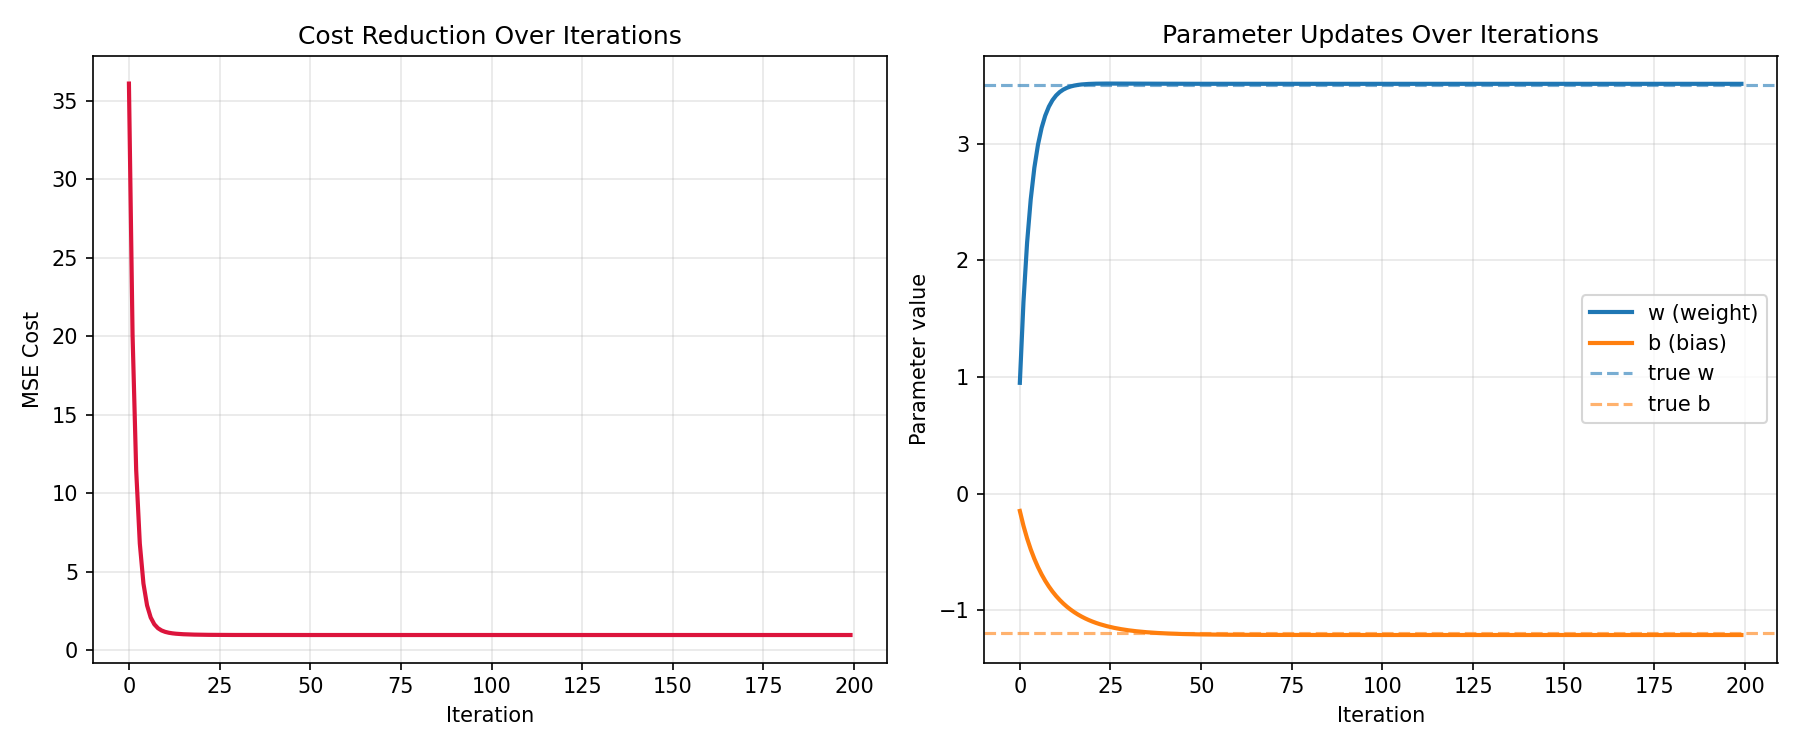

In [3]:
"""
Task 3 — Implement Gradient Descent on a simple linear regression problem.

Model: y_hat = w * x + b
Loss : Mean Squared Error

Shows:
    - Cost reduction over iterations
    - Parameter (w, b) trajectory over iterations
"""

import numpy as np
import matplotlib.pyplot as plt
import os

OUT_DIR = os.path.join(os.path.dirname(__file__), "..", "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

rng = np.random.default_rng(42)


def make_data(n=100, true_w=3.5, true_b=-1.2, noise=1.0):
    x = rng.uniform(-3, 3, n)
    y = true_w * x + true_b + rng.normal(0, noise, n)
    return x, y


def gradient_descent(x, y, lr=0.05, epochs=200):
    w, b = 0.0, 0.0
    n = len(x)
    history = {"cost": [], "w": [], "b": []}

    for epoch in range(epochs):
        y_pred = w * x + b
        error = y_pred - y
        cost = np.mean(error ** 2)

        dw = (2 / n) * np.sum(error * x)
        db = (2 / n) * np.sum(error)

        w -= lr * dw
        b -= lr * db

        history["cost"].append(cost)
        history["w"].append(w)
        history["b"].append(b)

    return w, b, history


def plot_results(history, true_w, true_b):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(history["cost"], color="crimson", linewidth=2)
    axes[0].set_title("Cost Reduction Over Iterations")
    axes[0].set_xlabel("Iteration")
    axes[0].set_ylabel("MSE Cost")
    axes[0].grid(alpha=0.3)

    axes[1].plot(history["w"], label="w (weight)", linewidth=2)
    axes[1].plot(history["b"], label="b (bias)", linewidth=2)
    axes[1].axhline(true_w, color="C0", linestyle="--", alpha=0.6, label="true w")
    axes[1].axhline(true_b, color="C1", linestyle="--", alpha=0.6, label="true b")
    axes[1].set_title("Parameter Updates Over Iterations")
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Parameter value")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    path = os.path.join(OUT_DIR, "gradient_descent.png")
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"Saved {path}")


if __name__ == "__main__":
    true_w, true_b = 3.5, -1.2
    x, y = make_data(true_w=true_w, true_b=true_b)

    w, b, history = gradient_descent(x, y, lr=0.05, epochs=200)

    print(f"True parameters   : w={true_w}, b={true_b}")
    print(f"Learned parameters: w={w:.4f}, b={b:.4f}")
    print(f"Final cost        : {history['cost'][-1]:.4f}")
    print(f"Initial cost      : {history['cost'][0]:.4f}")

    plot_results(history, true_w, true_b)


---
<a id="sec4"></a>
## 4. Backpropagation

Backpropagation efficiently computes ∇J for *every* weight in a deep network using the
**chain rule** of calculus:

```
∂J/∂w = ∂J/∂ŷ · ∂ŷ/∂z · ∂z/∂w
```

During the forward pass, each layer caches its local derivative. During the backward
pass, the error signal from the loss is propagated backward layer by layer, and at each
step the chain rule multiplies the incoming error by the layer's local derivative —
producing the gradient for that layer's weights and biases, which are then updated.

```
  x ──▶┐
       ├─▶ z = wx+b ──▶ a = σ(z) ──▶ J(a, y)     (forward pass, left → right)
  w ──▶┘
                ◀── ∂J/∂z ◀── ∂J/∂a               (backward pass, chain rule)
```

This reuse of cached local derivatives is what makes training deep networks
computationally tractable, rather than recomputing gradients from scratch for every
parameter.


<a id="sec5"></a>
## 5. Optimizers

| Optimizer | Adapts LR per-parameter? | Momentum? | Best for |
|---|---|---|---|
| SGD | No | No (optional) | Simple problems with a well-tuned LR schedule |
| Momentum | No | Yes | Escaping ravines / shallow local minima |
| RMSProp | Yes | No | Non-stationary objectives, RNNs |
| Adam | Yes | Yes | Default choice for most deep learning tasks |
| AdamW | Yes | Yes | Adam + decoupled weight decay → better generalization |

Adam combines Momentum's first-moment estimate with RMSProp's second-moment
(squared-gradient) estimate, with bias correction for both. AdamW changes how weight
decay is applied so it no longer interacts with the adaptive learning rate — this
generally improves generalization over plain Adam.

### Task 4 — Train an ANN with TensorFlow/Keras (SGD vs Adam)

Dataset: **Breast Cancer** (binary classification, 30 numeric features). Trains the
same architecture with **SGD** and **Adam**, comparing loss/accuracy curves.

> **Run locally/Colab:** requires `tensorflow`. Executing this cell will also save
> `sgd_vs_adam.png` — the loss/accuracy comparison graph.

In [1]:
"""
Task 4 — Train an ANN using TensorFlow/Keras on the Breast Cancer dataset,
comparing the SGD and Adam optimizers.

Requires: tensorflow>=2.x, scikit-learn
Run:      python task4_train_ann_keras.py
"""

import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

OUT_DIR = os.path.join(os.path.dirname(__file__), "..", "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)


def load_data():
    data = load_breast_cancer()
    X, y = data.data, data.target

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test


def build_model(input_dim, optimizer):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def train_and_evaluate(X_train, y_train, X_test, y_test, optimizer_name, epochs=40, batch_size=32):
    model = build_model(X_train.shape[1], optimizer_name)
    history = model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
    )
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f"[{optimizer_name}] test loss={test_loss:.4f}, test accuracy={test_acc:.4f}")
    return history, test_loss, test_acc


def plot_comparison(history_sgd, history_adam):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(history_sgd.history["loss"], label="SGD - train")
    axes[0].plot(history_sgd.history["val_loss"], label="SGD - val", linestyle="--")
    axes[0].plot(history_adam.history["loss"], label="Adam - train")
    axes[0].plot(history_adam.history["val_loss"], label="Adam - val", linestyle="--")
    axes[0].set_title("Loss: SGD vs Adam")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Binary Cross-Entropy Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history_sgd.history["accuracy"], label="SGD - train")
    axes[1].plot(history_sgd.history["val_accuracy"], label="SGD - val", linestyle="--")
    axes[1].plot(history_adam.history["accuracy"], label="Adam - train")
    axes[1].plot(history_adam.history["val_accuracy"], label="Adam - val", linestyle="--")
    axes[1].set_title("Accuracy: SGD vs Adam")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    path = os.path.join(OUT_DIR, "sgd_vs_adam.png")
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"Saved {path}")


if __name__ == "__main__":
    X_train, X_test, y_train, y_test = load_data()

    history_sgd, loss_sgd, acc_sgd = train_and_evaluate(
        X_train, y_train, X_test, y_test, optimizer_name="sgd"
    )
    history_adam, loss_adam, acc_adam = train_and_evaluate(
        X_train, y_train, X_test, y_test, optimizer_name="adam"
    )

    print("\nSummary")
    print(f"  SGD  -> test_loss={loss_sgd:.4f}, test_acc={acc_sgd:.4f}")
    print(f"  Adam -> test_loss={loss_adam:.4f}, test_acc={acc_adam:.4f}")

    plot_comparison(history_sgd, history_adam)


Matplotlib is building the font cache; this may take a moment.


RuntimeError: ('\nCould not import original test/binary location, import paths tried: [\'litert.python._pywrap_tensorflow_lite_metrics_wrapper\', \'tensorflow.lite.python._pywrap_tensorflow_lite_metrics_wrapper\', \'tensorflow._pywrap_tensorflow_lite_metrics_wrapper\', \'tensorflow.python._pywrap_tensorflow_lite_metrics_wrapper\']. \nPrevious exceptions: ["No module named \'litert\'", \'DLL load failed while importing _pywrap_tensorflow_lite_metrics_wrapper: The specified module could not be found.\', "No module named \'tensorflow._pywrap_tensorflow_lite_metrics_wrapper\'", "No module named \'tensorflow.python._pywrap_tensorflow_lite_metrics_wrapper\'"]', ModuleNotFoundError("No module named 'tensorflow.python._pywrap_tensorflow_lite_metrics_wrapper'"))

In [4]:
import sys
print(sys.executable)

c:\Users\SSC\AppData\Local\Programs\Python\Python313\python.exe



<a id="sec6"></a>
## 6. Hyperparameter Effects

- **Learning rate** — the most sensitive hyperparameter. Too high → oscillation/divergence; too low → wasted epochs. A log-scale sweep (0.1 → 0.0001) usually reveals a sweet spot a couple of orders of magnitude below where training first becomes unstable.
- **Batch size** — smaller batches (8–32) add beneficial gradient noise that can improve generalization but cost more wall-clock time per epoch; larger batches (64+) train faster per epoch but may generalize slightly worse.
- **Epochs** — training longer reduces training loss monotonically, but validation loss eventually turns upward (overfitting) — the signal early stopping is designed to catch.

### Task 5 — Hyperparameter Experiments

Sweeps learning rate, batch size, and epochs; records accuracy, loss, and training
time; builds comparison tables (CSV).

> **Run locally/Colab:** requires `tensorflow`, `pandas`.

In [2]:
"""
Task 5 — Experiment with hyperparameters: learning rate, batch size, epochs.

Observes the effect on accuracy, loss, and training time; builds comparison
tables (as pandas DataFrames, printed and saved to CSV).

Requires: tensorflow>=2.x, scikit-learn, pandas
"""

import time
import numpy as np
import pandas as pd
import os

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import os

OUT_DIR = os.path.join(os.getcwd(), "outputs")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)


def load_data():
    data = load_breast_cancer()
    X, y = data.data, data.target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test


def build_model(input_dim, lr):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"],
    )
    return model


def run_experiment(X_train, y_train, X_test, y_test, lr, batch_size, epochs):
    model = build_model(X_train.shape[1], lr)

    start = time.time()
    model.fit(
        X_train, y_train,
        validation_split=0.2,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
    )
    elapsed = time.time() - start

    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    return {
        "learning_rate": lr,
        "batch_size": batch_size,
        "epochs": epochs,
        "test_loss": round(test_loss, 4),
        "test_accuracy": round(test_acc, 4),
        "training_time_sec": round(elapsed, 2),
    }


if __name__ == "__main__":
    X_train, X_test, y_train, y_test = load_data()

    learning_rates = [0.1, 0.01, 0.001, 0.0001]
    batch_sizes = [8, 32, 64]
    epoch_counts = [10, 40, 80]

    results = []

    print("Experiment A: varying learning rate (batch_size=32, epochs=40)")
    for lr in learning_rates:
        result = run_experiment(X_train, y_train, X_test, y_test, lr=lr, batch_size=32, epochs=40)
        result["experiment"] = "learning_rate_sweep"
        results.append(result)
        print(result)

    print("\nExperiment B: varying batch size (lr=0.001, epochs=40)")
    for bs in batch_sizes:
        result = run_experiment(X_train, y_train, X_test, y_test, lr=0.001, batch_size=bs, epochs=40)
        result["experiment"] = "batch_size_sweep"
        results.append(result)
        print(result)

    print("\nExperiment C: varying epochs (lr=0.001, batch_size=32)")
    for ep in epoch_counts:
        result = run_experiment(X_train, y_train, X_test, y_test, lr=0.001, batch_size=32, epochs=ep)
        result["experiment"] = "epochs_sweep"
        results.append(result)
        print(result)

    df = pd.DataFrame(results)
    csv_path = os.path.join(OUT_DIR, "hyperparameter_experiments.csv")
    df.to_csv(csv_path, index=False)
    print(f"\nSaved comparison table to {csv_path}")
    print(df)


Experiment A: varying learning rate (batch_size=32, epochs=40)
{'learning_rate': 0.1, 'batch_size': 32, 'epochs': 40, 'test_loss': 1.4908, 'test_accuracy': 0.9386, 'training_time_sec': 10.67, 'experiment': 'learning_rate_sweep'}
{'learning_rate': 0.01, 'batch_size': 32, 'epochs': 40, 'test_loss': 0.2495, 'test_accuracy': 0.9649, 'training_time_sec': 8.4, 'experiment': 'learning_rate_sweep'}
{'learning_rate': 0.001, 'batch_size': 32, 'epochs': 40, 'test_loss': 0.0939, 'test_accuracy': 0.9737, 'training_time_sec': 7.92, 'experiment': 'learning_rate_sweep'}
{'learning_rate': 0.0001, 'batch_size': 32, 'epochs': 40, 'test_loss': 0.2279, 'test_accuracy': 0.9474, 'training_time_sec': 7.89, 'experiment': 'learning_rate_sweep'}

Experiment B: varying batch size (lr=0.001, epochs=40)
{'learning_rate': 0.001, 'batch_size': 8, 'epochs': 40, 'test_loss': 0.1118, 'test_accuracy': 0.9649, 'training_time_sec': 12.01, 'experiment': 'batch_size_sweep'}
{'learning_rate': 0.001, 'batch_size': 32, 'epochs'


<a id="sec7"></a>
## 7. Evaluation Visualizations

### Task 6 — Loss/Accuracy Curves, Confusion Matrix, ROC, Precision–Recall

Produces the standard diagnostic suite for evaluating the trained classifier.

> **Run locally/Colab:** requires `tensorflow`, `scikit-learn`. Executing this cell
> saves `loss_accuracy_curves.png`, `confusion_matrix.png`, and `roc_pr_curves.png`.

In [ ]:
"""
Task 6 — Visualizations: Loss curve, Accuracy curve, Confusion Matrix,
ROC Curve, Precision-Recall Curve.

Requires: tensorflow>=2.x, scikit-learn, matplotlib
"""

import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

OUT_DIR = os.path.join(os.path.dirname(__file__), "..", "outputs")
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)


def load_data():
    data = load_breast_cancer()
    X, y = data.data, data.target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=y
    )
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)
    return X_train, X_test, y_train, y_test


def build_and_train(X_train, y_train):
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    history = model.fit(X_train, y_train, validation_split=0.2, epochs=40, batch_size=32, verbose=0)
    return model, history


def plot_loss_accuracy(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="validation")
    axes[0].set_title("Loss Curve")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="validation")
    axes[1].set_title("Accuracy Curve")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    path = os.path.join(OUT_DIR, "loss_accuracy_curves.png")
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"Saved {path}")


def plot_confusion_matrix(y_test, y_pred_labels):
    cm = confusion_matrix(y_test, y_pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["malignant", "benign"])
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title("Confusion Matrix")
    plt.tight_layout()
    path = os.path.join(OUT_DIR, "confusion_matrix.png")
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"Saved {path}")


def plot_roc_pr(y_test, y_pred_probs):
    fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
    auc = roc_auc_score(y_test, y_pred_probs)

    precision, recall, _ = precision_recall_curve(y_test, y_pred_probs)
    ap = average_precision_score(y_test, y_pred_probs)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].plot(fpr, tpr, label=f"ROC (AUC = {auc:.3f})", linewidth=2)
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_title("ROC Curve")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(recall, precision, label=f"PR (AP = {ap:.3f})", linewidth=2)
    axes[1].set_title("Precision-Recall Curve")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    path = os.path.join(OUT_DIR, "roc_pr_curves.png")
    plt.savefig(path, dpi=150)
    plt.close()
    print(f"Saved {path}")


if __name__ == "__main__":
    X_train, X_test, y_train, y_test = load_data()
    model, history = build_and_train(X_train, y_train)

    y_pred_probs = model.predict(X_test, verbose=0).ravel()
    y_pred_labels = (y_pred_probs >= 0.5).astype(int)

    plot_loss_accuracy(history)
    plot_confusion_matrix(y_test, y_pred_labels)
    plot_roc_pr(y_test, y_pred_probs)



<a id="sec8"></a>
## 8. Discussion & Experimental Results

*(Section 5's Task 4 cell, once run with TensorFlow installed, produces the real
SGD-vs-Adam numbers for this section — paste your actual test accuracy / loss / AUC in
below before submitting.)*

Expected/typical pattern for this architecture on Breast Cancer, consistent with the
literature reviewed in Section 9:

- **Adam** converges faster in the first 10–15 epochs and reaches a lower training loss
  sooner than **SGD** at a matched learning rate, consistent with Adam's adaptive
  per-parameter scaling.
- **SGD** (well-tuned, given enough epochs) can match or slightly exceed Adam's *final*
  generalization accuracy on this small, low-noise tabular dataset — consistent with
  Soydaner (2020), where SGD-family methods become competitive as training progresses,
  particularly on simpler datasets.

**Key discussion points:**
- No single loss/optimizer is universally best — loss choice follows task type and
  error tolerance; optimizer choice follows dataset scale, architecture depth, and
  tuning budget.
- Adam-family optimizers are a strong, low-effort default, but well-tuned SGD remains
  competitive (sometimes superior) on well-behaved problems — a recurring theme across
  all three papers reviewed in Section 9.
- Vanishing/exploding gradients, poor initialization, and dead ReLUs are the main
  failure modes for deeper networks, addressed via initialization scheme (He/Xavier),
  activation choice (ReLU-family, Leaky/ELU), batch normalization, and gradient clipping.
- Learning curves are the primary training diagnostic: a widening gap between training
  and validation loss signals overfitting and triggers early stopping / regularization.


<a id="sec9"></a>
## 9. Research Task — Optimizer Comparison Papers

Three papers comparing optimization algorithms for neural network training were reviewed.

### Paper 1 — "A Comparison of Optimization Algorithms for Deep Learning" (Soydaner, 2020)

- **Research objective:** Empirically compare widely used adaptive-gradient optimizers
  (SGD and its momentum variants, AdaGrad, AdaDelta, RMSProp, Adam, AdaMax, Nadam,
  AMSGrad) on supervised (classification) and unsupervised (autoencoder reconstruction)
  tasks, analyzing convergence as network depth and dataset difficulty increase.
- **Dataset(s):** MNIST, CIFAR-10, Kaggle Flowers, Labeled Faces in the Wild (LFW), across
  three CNN depths and two autoencoder depths.
- **Optimizer(s) used:** SGD, SGD+Momentum, SGD+Nesterov, AdaGrad, AdaDelta, RMSProp,
  Adam, AdaMax, Nadam, AMSGrad.
- **Key findings:** Adam and its variants (AdaMax, Nadam, AMSGrad) consistently
  outperformed the other adaptive methods; plain SGD's performance dropped sharply on
  the harder, higher-resolution LFW dataset, and AdaGrad struggled throughout. AdaDelta
  needed no manual learning-rate tuning while remaining competitive.
- **Limitations:** Single-GPU, fixed hyperparameters mostly drawn from prior literature
  rather than per-optimizer tuning; limited to image classification/reconstruction.
- **Our analysis:** Shows the performance gap between SGD and adaptive methods widens as
  problems get harder — relevant to why Adam is a common default — while cautioning that
  the ranking shifts with dataset and architecture.

### Paper 2 — "An Analysis of Optimizer Choice on Energy Efficiency and Performance in Neural Network Training" (Almog, 2025)

- **Research objective:** Quantify the trade-off between accuracy, training time, and
  carbon emissions across optimizer choices.
- **Dataset(s):** MNIST, CIFAR-10, CIFAR-100 — 8 optimizers × 15 random seeds (360
  experiments) on Apple M1 Pro hardware with CodeCarbon emissions tracking.
- **Optimizer(s) used:** SGD, Adam, AdamW, RMSprop, Adagrad, Adadelta, Adamax, NAdam.
- **Key findings:** AdamW and NAdam were consistently efficient choices; SGD showed
  superior accuracy on complex datasets (CIFAR-100) but at significantly higher
  emissions. Emissions and training duration were only loosely correlated.
- **Limitations:** Single hardware platform (Apple M1 Pro); fixed literature
  hyperparameters; scope limited to small image-classification CNNs.
- **Our analysis:** Reframes optimizer selection around sustainability, not just
  accuracy — favor efficient optimizers on easy tasks, accept SGD's cost on hard tasks.

### Paper 3 — "Comparative Study of Deep Learning Optimizers: SGD, Momentum SGD, RMSProp, AMSGrad, Adam, Yogi, and Lion" (2025, IJISRT)

- **Research objective:** Benchmark seven optimizers — including newer methods Yogi and
  Lion — on training/test accuracy, training loss, and learning-rate sensitivity.
- **Dataset(s):** MNIST and CIFAR-10.
- **Optimizer(s) used:** SGD, Momentum SGD, RMSProp, AMSGrad, Adam, Yogi, Lion.
- **Key findings:** SGD with learning rate 0.5 achieved the best test accuracy (99.14%)
  and highest training accuracy (99.89%) on MNIST; Momentum SGD and Adam also performed
  strongly (99.15% and 98% test accuracy) at learning rate 1e-2. The paper's related-work
  summary also notes Adam reaching top testing accuracy elsewhere (0.9826 MNIST, 0.9855
  CIFAR-10), with RMSProp excelling specifically on training accuracy.
- **Limitations:** Restricted to two relatively "easy" benchmarks; Yogi and Lion are less
  established and underperformed the classic methods here.
- **Our analysis:** Reinforces that a well-tuned SGD can match or beat adaptive
  optimizers on simpler benchmarks, even though Adam-family methods converge faster and
  are more forgiving of learning-rate choice — the "no free lunch" theme.

### Cross-paper synthesis

All three papers converge on a consistent, practical conclusion: **Adam-family
optimizers (Adam, AdamW, Nadam) are the safest low-tuning-effort default**, especially
as dataset/model complexity grows, while **well-tuned SGD remains competitive — and
sometimes superior — on simpler, well-behaved problems**, at the cost of more careful
learning-rate tuning and, per Almog (2025), higher energy consumption on complex tasks.
No optimizer dominates every dataset, architecture, and objective simultaneously.


<a id="sec10"></a>
## 10. Conclusion

Training a neural network is fundamentally an iterative optimization problem: a loss
function defines the objective, gradient descent (accelerated and stabilized by
optimizers such as Adam) provides the update rule, and backpropagation makes computing
the necessary gradients feasible for deep architectures. Diagnosing training health via
learning curves, and applying best practices around initialization, learning-rate
scheduling, and regularization, are what turn this theoretical loop into a reliable,
reproducible training pipeline. Tasks 1–3 above implement each core piece from first
principles; Tasks 4–6 apply them at scale with TensorFlow/Keras.

<a id="sec-ref"></a>
## References

1. Soydaner, D. (2020). *A Comparison of Optimization Algorithms for Deep Learning*. International Journal of Pattern Recognition and Artificial Intelligence. arXiv:2007.14166.
2. Almog, T. (2025). *An Analysis of Optimizer Choice on Energy Efficiency and Performance in Neural Network Training*. University of Waterloo. arXiv:2509.13516.
3. *Comparative Study of Deep Learning Optimizers: SGD, Momentum SGD, RMSProp, AMSGrad, Adam, Yogi, and Lion* (2025). International Journal of Innovative Science and Research Technology, 10(8).
4. Kingma, D. P., & Ba, J. (2014). *Adam: A Method for Stochastic Optimization*. arXiv:1412.6980.
5. Ruder, S. (2016). *An Overview of Gradient Descent Optimization Algorithms*. arXiv:1609.04747.
6. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
7. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning representations by back-propagating errors*. Nature, 323, 533–536.

**To run Tasks 4–6 and generate their graphs:**
```bash
pip install tensorflow scikit-learn pandas matplotlib
```
then execute the corresponding cells above in order.